# Plan

This is a computationally cheap example done with Krylov methods, hash basis methods, and petsc4py slepc4py. 

If we simply set
NiPS3_ed['nd'] = 3 
NiPS3_rixs['v_noccu'] = NiPS3_ed['nd'] + NiPS3_ed['nbath']*norb_d['norb_d']

then we will be at the planned computational cost. 




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from wrappers import ed_wrapper, rixs_wrapper, NiPS3_ed, NiPS3_rixs
from mpi4py import MPI
comm = MPI.COMM_WORLD

%matplotlib widget

# ED solve

In [2]:
eval_i_F, denmat, noccu_gs = ed_wrapper(comm, **NiPS3_ed)

edrixs >>> Running ED ...

    Summary of Slater integrals:
    ------------------------------
    Terms,  Initial Hamiltonian,  Intermediate Hamiltonian
     F0_vv :          7.8800000000        7.8800000000
     F2_vv :         10.6800000000       10.6800000000
     F4_vv :          6.6800000000        6.6800000000
     F0_vc :          0.0000000000        7.4500000000
     F2_vc :          0.0000000000        6.5600000000
     G1_vc :          0.0000000000        4.9200000000
     G3_vc :          0.0000000000        2.8000000000
     F0_cc :          0.0000000000        0.0000000000
     F2_cc :          0.0000000000        0.0000000000


    Summary of Slater integrals:
    ------------------------------
    Terms,  Initial Hamiltonian,  Intermediate Hamiltonian
     F0_vv :          7.8800000000        7.8800000000
     F2_vv :         10.6800000000       10.6800000000
     F4_vv :          6.6800000000        6.6800000000
     F0_vc :          0.0000000000        7.4500000000
  

In [3]:
out = ed_wrapper(comm, fortran=False, **NiPS3_ed)
eval_i, evec_i, emat_i, emat_n, umat_i, umat_n = out

edrixs >>> Running ED ...

    Summary of Slater integrals:
    ------------------------------
    Terms,  Initial Hamiltonian,  Intermediate Hamiltonian
     F0_vv :          7.8800000000        7.8800000000
     F2_vv :         10.6800000000       10.6800000000
     F4_vv :          6.6800000000        6.6800000000
     F0_vc :          0.0000000000        7.4500000000
     F2_vc :          0.0000000000        6.5600000000
     G1_vc :          0.0000000000        4.9200000000
     G3_vc :          0.0000000000        2.8000000000
     F0_cc :          0.0000000000        0.0000000000
     F2_cc :          0.0000000000        0.0000000000

    Summary of Slater integrals:
    ------------------------------
    Terms,  Initial Hamiltonian,  Intermediate Hamiltonian
     F0_vv :          7.8800000000        7.8800000000
     F2_vv :         10.6800000000       10.6800000000
     F4_vv :          6.6800000000        6.6800000000
     F0_vc :          0.0000000000        7.4500000000
   

In [4]:
np.testing.assert_allclose(eval_i, eval_i_F)

In [5]:
# RIXS

In [6]:
from importlib import reload
import wrappers
reload(wrappers)
import solvers
reload(solvers)

rixs_F, poles_F = rixs_wrapper(comm, fortran=True, **NiPS3_rixs)

edrixs >>> Running RIXS ...

edrixs >>> Calculate RIXS for incident energy:  850.5
edrixs >>> Polarization:  0
  fedrixs >>> RIXS Begin ...

     num_val_orbs:               20
     num_core_orbs:               6
     ndim_i:                    190
     ndim_n:                    120
     ndim_f:                    190
     nhopp_i:                   218
     nhopp_n:                   228
     ncoul_i:                   340
     ncoul_n:                   932
     num_gs:                      3
     nkryl:                     200
     linsys_max:               1000
     linsys_tol:           0.10E-09
     omega_in:           850.500000
     gamma_in              0.600000

  fedrixs >>> For initial state:             1
     Building transition operator for absorption process ...
     Done !

     Apply transition operator on the ground state to get intermediate state...
     Done !

     Building Hamiltonian for intermediate configuration ...
     Allocate memory for ham_csr ...
     R

In [7]:
rixs, poles = rixs_wrapper(comm, fortran=False, **NiPS3_rixs,
             eval_i=eval_i,
             evec_i=evec_i,
             emat_i=emat_i,
             umat_i=umat_i,
             emat_n=emat_n,
             umat_n=umat_n,
            )

In [8]:
rixs.shape

(22, 225, 2)

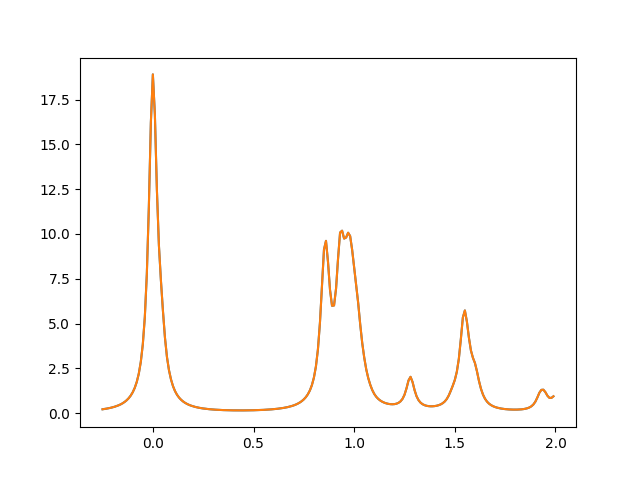

In [9]:
fig, ax = plt.subplots()

ax.plot(NiPS3_rixs['eloss'], rixs.sum((0, 2)))
ax.plot(NiPS3_rixs['eloss'], rixs_F.sum((0, 2)))

In [11]:
np.testing.assert_allclose(rixs, rixs_F, atol=1e-4)

In [ ]:
fig, ax = plt.subplots()

art = ax.pcolor(NiPS3_rixs['ominc'], NiPS3_rixs['eloss'], rixs.sum(-1).T)
plt.colorbar(art, ax=ax)
ax.set_xlabel("Incident energy (eV)")
ax.set_ylabel("Energy loss (eV)")

In [ ]:
np.testing.assert_allclose(rixs, rixs_F, atol=1e-5, rtol=1e-5)